# 📊 Statistical Hypothesis Testing: Ultimate vs. Surf Profitability

To move beyond simple averages, we must determine if the difference in revenue between our two plans is statistically significant. This section uses rigorous mathematical testing to validate our business observations.

### 🧪 Testing Objective
* **🎯 Primary Goal**: Determine if the monthly profit per user differs significantly between the **Ultimate** and **Surf** plans.
* **⚖️ Hypotheses**:
    * **Null ($H_0$)**: There is no significant difference in the distribution of profit between the two plans.
    * **Alternative ($H_a$)**: The profit distributions for the two plans are significantly different.

### 🔍 Step 1: Normality Diagnostics
Before selecting a test, we must verify the "shape" of our data. Parametric tests (like the T-test) assume a Bell Curve, while non-parametric tests are required for skewed data.
* **📈 Analytical Check**: We use the **Shapiro-Wilk Test**. A $p$-value < 0.05 formally rejects the assumption of normality.
* **📉 Visual Check**: We use **Q-Q Plots** and **Histograms** to identify "floor effects" (base plan costs) and extreme outliers (heavy overage users).

### 🛡️ Step 2: The Mann-Whitney U Test
Because our data is heavily skewed and contains significant outliers, we utilize the **Mann-Whitney U Test** (a non-parametric alternative to the Independent T-test).
* **⚡ Robustness**: Unlike a T-test, this method compares **ranks** rather than means, ensuring the result is not unfairly biased by a small number of "whale" users paying extremely high overages.
* **📏 Effect Size ($r$)**: We calculate the **Rank-Biserial Correlation** to measure the practical magnitude of the difference. This categorizes the result as "Small," "Medium," or "Large" to provide business context beyond a simple $p$-value.

### 🎨 Step 3: Visualizing the "Business Story"
We use advanced visualizations to provide a qualitative check on our mathematical results:

* **Box Plots**: These highlight the Median and Interquartile Range (IQR), making it easy to see the difference in the "typical" user's bill and the spread of outliers.
* **Violin Plots**: These illustrate the Density of users, visually proving where the "bulge" of customers exists (e.g the 70 USD fixed code cluster for Ultimate vs. the wider 20+ USD distribution for Surf).

# 🛠️ Environment Setup: Library Imports & Data Access

To conduct our statistical analysis, we must first initialize our workspace with the necessary data science toolkits. Each library plays a specific role in our pipeline, from data manipulation to advanced mathematical modeling.

### 📚 Core Libraries:
* **Pandas & NumPy**: Used for high-performance data manipulation, handling our master dataset, and performing vectorized numerical operations.
* **Matplotlib & Seaborn**: Our primary visualization engine. We use Seaborn specifically for its advanced statistical plotting capabilities (Box Plots and Violin Plots).
* **Scipy (Stats)**: Provides the mathematical backbone for our **Shapiro-Wilk** and **Mann-Whitney U** tests.

### 📂 Data Access:
* **Google Drive Integration**: We mount our external drive to securely access the source CSV files. This ensures data persistence across different Colab sessions.

In [13]:
# import needed libraries
import matplotlib.pyplot as plt
from   scipy import stats
import seaborn as sns
import pandas  as pd
import numpy   as np

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 📂 Data Loading & Initial Quality Assessment

Before proceeding with our statistical testing, we must import our master dataset and verify its structural integrity. This step ensures that our data merge was successful and that we are working with the expected dimensions and data types.

### 📥 Dataset Loading
We load the `merged_data.csv` file directly from our mounted Google Drive. This file represents our consolidated user activity, containing all usage metrics (calls, messages, and internet) alongside plan-specific information.

### 🔍 Data Verification & Audit:
* **Structural Summary**: We verify the total count of observations (rows) and features (columns) to ensure the dataset matches our expected population size.
* **Schema Inspection**: Using `.info()`, we confirm that numerical columns (like `monthly_profit`) are correctly typed and that categorical labels (like `plan_name`) are properly recognized.
* **Missing Value Analysis**:
    * We calculate both the absolute count and the percentage of null values per column.
    * **Integrity Check**: Since we previously filled missing usage values with **0**, we expect to find no missing data in our primary analytical columns. This check acts as a final "Data Cleanliness" safeguard before we enter the hypothesis testing phase.

### 🛠️ Data Summary Output
The following code block generates a high-level summary of the dataset's current state, including a specialized breakdown of any remaining missing values.

In [4]:
merged_data_path = "/content/drive/MyDrive/Colab Notebooks/levels of data/level 3/merged_data.csv"
data = pd.read_csv(merged_data_path)

print("\n"+"="*50)
print("Basic Data Information")
print("="*50)
print(f"Total Rows: {data.shape[0]}")
print(f"Total Columns:{data.shape[1]}")

print("\n"+"="*50)
print("Columns Information")
print("="*50)
print(data.info())

print("\n"+"="*50)
print("Missing Values Analysis")
print("="*50)
missing_data = data.isnull().sum() # count values of missing data
missing_data_perecent = (missing_data/len(data))*100

#define missing dataframe
missing_df = pd.DataFrame ({
    "column ": missing_data.index,
    "missing_count": missing_data.values,
    "missing_perecent": missing_data_perecent.values
})

missing_dataframe = missing_df[missing_df['missing_count']>0].sort_values('missing_count',ascending = False)
if len(missing_dataframe)>0 :
  print(missing_dataframe.to_string(index=False))
else :
  print("no missing values found")


Basic Data Information
Total Rows: 2243
Total Columns:29

Columns Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2243 entries, 0 to 2242
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  2243 non-null   int64  
 1   first_name               2243 non-null   object 
 2   last_name                2243 non-null   object 
 3   age                      2243 non-null   int64  
 4   city                     2243 non-null   object 
 5   reg_date                 2243 non-null   object 
 6   plan                     2243 non-null   object 
 7   churn_date               126 non-null    object 
 8   month                    2221 non-null   object 
 9   calls_duration           2243 non-null   float64
 10  messages_count           2243 non-null   float64
 11  mb_used                  2243 non-null   float64
 12  gb_used                  2243 non-null   float64
 13 

These 22 rows represent customers who registered for service but had
NO activity (no calls, no messages, no internet usage) during 2018.

Since the 'month' column is extracted from activity dates (call_date,
message_date, session_date), customers with zero activity have no
valid month value.

To properly analyze these inactive customers, we would need to:
1. Generate rows for each month from reg_date to churn_date
2. For customers without churn_date, generate until end of 2018
3. Assign zero usage for all months
4. Calculate base subscription fees without overage charges

However, for this analysis focused on usage patterns and profit from
active customers, we will DROP these rows to maintain data quality
and avoid complications in our profit calculations.


# 🧹 Data Refinement: Handling Inactive Subscriptions

During our initial data audit, we identified **22 rows** with missing values in the `month` column. Upon closer inspection, these rows represent a specific segment of our user base that requires specialized handling.

### 🔍 Root Cause Analysis: The "Zero Activity" Segment
These 22 rows represent customers who registered for the service but had **NO recorded activity** (no calls, no messages, and no internet usage) during the 2018 fiscal year.

Since our `month` column is derived directly from activity timestamps (`call_date`, `message_date`, and `session_date`), customers with zero activity possess no valid temporal markers, resulting in `NaN` values.

### 🛠️ Alternative Handling Strategy
To perfectly account for these inactive customers, a rigorous approach would involve:
1. **Time-Series Generation**: Creating rows for every month from their `reg_date` to their `churn_date`.
2. **Calendar Padding**: For active customers without a `churn_date`, generating rows through the end of 2018.
3. **Zero-Usage Assignment**: Manually assigning a value of **0** for all usage metrics.
4. **Base Fee Calculation**: Applying only the flat subscription fee without any overage charges.

### ⚖️ Decision: Row Exclusion
However, since the primary objective of this specific analysis is to evaluate **usage patterns** and **profitability dynamics** from active participants, we have elected to **DROP** these 22 rows.

**Rationale**: This maintains the high quality of our activity-based dataset and avoids introducing artificial bias or unnecessary complexity into our profit calculations for this phase of the study.

In [54]:
print("="*50)
print("Month Columns Has Some Missing Rows ")
print("="*50)

print(f"\nTotal rows before dropping : {len(data)}")
missing_month_count = data['month'].isnull().sum()
print(f"Rows with missing 'month': {missing_month_count}")

#drop rows with missing month
data = data.dropna(subset=['month'])
print("Rows with missing 'month' dropped successfully")
print(f"Total Rows after dropping : {len(data)}")
print(f"Rows Removed: {missing_month_count}")

print("\n"+"="*50)
print("VERIFICATION : CHECKING MISSING VALUES AFTER DROPPING")
print("="*50)
remaining_missing= data['month'].isnull().sum()
print(f"Missing values in 'month' column : {remaining_missing}")
if remaining_missing == 0 :
  print("All rows now have valid 'month' values ")
else :
  print("Warning: some missing values still remain")


Month Columns Has Some Missing Rows 

Total rows before dropping : 2221
Rows with missing 'month': 0
Rows with missing 'month' dropped successfully
Total Rows after dropping : 2221
Rows Removed: 0

VERIFICATION : CHECKING MISSING VALUES AFTER DROPPING
Missing values in 'month' column : 0
All rows now have valid 'month' values 


# 🧪 Normality Diagnostics & Test Selection

Before performing our formal hypothesis test, we must determine if the distribution of **Monthly Profit** follows a "Normal Distribution" (Bell Curve). This is a critical step because it dictates whether we use **Parametric tests** (like the Independent T-test) or **Non-Parametric tests** (like Mann-Whitney U).

To ensure the highest level of statistical rigor, we will evaluate normality using a **Four-Way Diagnostic Approach**:

### 📊 Analytical Tests (The Mathematical Perspective)
These tests provide objective numerical evidence to support or reject the assumption of normality:
* **Shapiro-Wilk Test**: This is our primary statistical test. A $p$-value < 0.05 indicates that the data significantly deviates from a normal distribution.
* **Skewness & Kurtosis Analysis**:
    * **Skewness** measures the symmetry of the distribution (whether it has a long tail to the left or right).
    * **Kurtosis** measures the "tailedness" or peak of the distribution. High kurtosis suggests that outliers are driving the profit variance.

### 📈 Graphical Tests (The Visual Perspective)
Visualizations help us understand *how* the data is non-normal and identify specific business patterns:
* **Histograms with KDE**: We will plot the actual distribution of profits to see if they cluster around the base plan prices ($20 and $70) or follow a smooth curve.
* **Q-Q Plots (Quantile-Quantile)**: We will compare our data against a theoretical normal line. If the points "curve away" from the 45-degree line, it confirms that the data is non-normal.

### ⚖️ Decision Framework
By combining these four methods, we ensure that our final choice of statistical test is robust and accurately reflects the underlying business reality of our calling plans.

# 📈  Shapiro-Wilk Test for Normality

The Shapiro-Wilk test is our primary mathematical tool for determining if the profit data follows a normal distribution. We run this test separately for each plan to see if our data meets the requirements for a parametric T-test.

### ⚖️ The Hypothesis Framework:
* **Null Hypothesis ($H_0$)**: The data is normally distributed.
* **Alternative Hypothesis ($H_a$)**: The data is **not** normally distributed.
* **Significance Level ($\alpha$)**: **0.05**

### 🔍 Decision Rule:
* **If $p > 0.05$**: We fail to reject $H_0$. The data is likely **Normal**.
* **If $p < 0.05$**: We reject $H_0$. The data is **Not Normal**.

### 🛠️ Implementation Strategy:
The following code iterates through each plan, extracts the `monthly_profit` values, and calculates the Shapiro-Wilk statistic and $p$-value. It concludes with a summary table for a side-by-side comparison of both plans.


In [16]:
print("="*50)
print("NORMALITY TEST : MONTHLY PROFIT BY PLAN")
print("="*50)

# get unique plans names
plans = data['plan_name'].unique()
print(f"\nPlans in dataset :{plans}")
print(f"Numbers of plans : {len(plans)}")

# SHAPIRO-WILK TEST
print("="*50)
print("SHAPIRO-WILK TEST")
print("="*50)

#store results of analysis
shapiro_results = []

for plan in plans :
  plan_data = data[data['plan_name'] == plan]['monthly_profit']
  #rund shapiro_wilk test
  statistic, p_value = stats.shapiro(plan_data)
  #check normality
  is_normal = "Yes(Normal)" if p_value > 0.05 else "No (Not Normal)"
  #store results
  shapiro_results.append({
      'plan'       : plan,
      'sample_size': len(plan_data),
      'statistic'  : statistic,
      "P-value"    :p_value,
      "Normal?"    :is_normal
  })
  print(f"\nSample Size : {len(plan_data)}")
  print(f"Test Statistic : {statistic:.6f}")
  print(f"p-value : {p_value:.6f}")
  print(f"Normality : {is_normal}")

# Create summary dataframe
shapiro_df = pd.DataFrame(shapiro_results)
print("\n" + "="*70)
print("SHAPIRO-WILK TEST SUMMARY")
print("="*70)
print(shapiro_df.to_string(index=False))

NORMALITY TEST : MONTHLY PROFIT BY PLAN

Plans in dataset :['ultimate' 'surf']
Numbers of plans : 2
SHAPIRO-WILK TEST

Sample Size : 701
Test Statistic : 0.206256
p-value : 0.000000
Normality : No (Not Normal)

Sample Size : 1520
Test Statistic : 0.742041
p-value : 0.000000
Normality : No (Not Normal)

SHAPIRO-WILK TEST SUMMARY
    plan  sample_size  statistic      P-value         Normal?
ultimate          701   0.206256 3.579522e-47 No (Not Normal)
    surf         1520   0.742041 1.659853e-43 No (Not Normal)


# 📈 Skewness & Kurtosis (Numerical Diagnostics)

While the Shapiro-Wilk test is effective for small samples, **Skewness** and **Kurtosis** provide a more robust analytical view for larger datasets. These metrics allow us to quantify exactly how much our profit distribution "leans" or "bulges" compared to a perfect normal curve.

### 📐 Understanding the Metrics:
* **SKEWNESS (Symmetry Check)**:
    * **≈ 0**: Symmetric (Normal-like).
    * **> 0**: Right-skewed (Long tail of high-profit "outliers").
    * **< 0**: Left-skewed (Tail on the lower end).
    * **|Skewness| > 1**: Indicates a highly skewed, non-normal distribution.

* **KURTOSIS (Tail Heaviness/Outliers)**:
    * **≈ 0**: Normal distribution tails.
    * **> 0**: Heavy tails (indicates the presence of extreme profit values).
    * **< 0**: Light tails (data is thin at the ends).
    * **|Kurtosis| > 1**: Indicates a significant deviation from normality.

### 🛠️ Implementation Strategy:
The following code calculates these descriptive statistics for both the **Ultimate** and **Surf** plans. By comparing the **Mean** to the **Median** and checking the Skewness/Kurtosis values, we can mathematically confirm if the "average" user is representative of the whole group or if outliers are pulling the results.

In [34]:
# another analyticall ways
print("="*50)
print("DESCRIPTIVE STATISTICS TEST BY PLAN")
print("="*50)

for plan in plans:
  plan_data = data[data['plan_name'] == plan]['monthly_profit']
  print(f"\nPlan : {plan}")
  print(f"Mean : ${plan_data.mean():.2f}")
  print(f"Medain:${plan_data.median():.2f}")
  print(f"std Dev : ${plan_data.std():.2f}")
  print(f"Skewness : {plan_data.skew():.2f}")
  print(f"Kurtosis : {plan_data.kurtosis():.2f}")
  print(f"Min : ${plan_data.min():.2f}")
  print(f"Max : ${plan_data.max():.2f}")


DESCRIPTIVE STATISTICS TEST BY PLAN

Plan : ultimate
Mean : $72.30
Medain:$70.00
std Dev : $11.44
Skewness : 6.11
Kurtosis : 42.25
Min : $70.00
Max : $182.00

Plan : surf
Mean : $59.57
Medain:$40.00
std Dev : $53.48
Skewness : 2.48
Kurtosis : 10.97
Min : $20.00
Max : $590.37


# 📈 Q-Q Plots (Graphical Diagnostics)

The **Quantile-Quantile (Q-Q) Plot** is a visual tool used to compare our actual profit distribution against a theoretical "Normal" distribution. This helps us see exactly where our data breaks the rules of normality (e.g., at the very low end or very high end of the price range).

### 🔍 Visual Interpretation:
* **Diagonal Reference Line (Red)**: This represents a perfect normal distribution.
* **Data Points (Blue)**:
    * **Following the line**: Indicates the data is likely normal.
    * **Deviating from the line**: Confirms the data is **NOT** normal.
    * **Curves at the ends**: Indicates "Heavy Tails," meaning our dataset has more extreme outliers than a normal distribution would allow.

### 🛠️ Implementation Strategy:
The following code generates side-by-side Q-Q plots for the **Ultimate** and **Surf** plans. We customize the markers and line widths to make the deviations clearly visible. If the blue dots "peel away" from the red line, it provides visual proof that we must move toward a non-parametric statistical test.


Q-Q pLOTS  (QUANTILE-QUANTILE PLOTS)


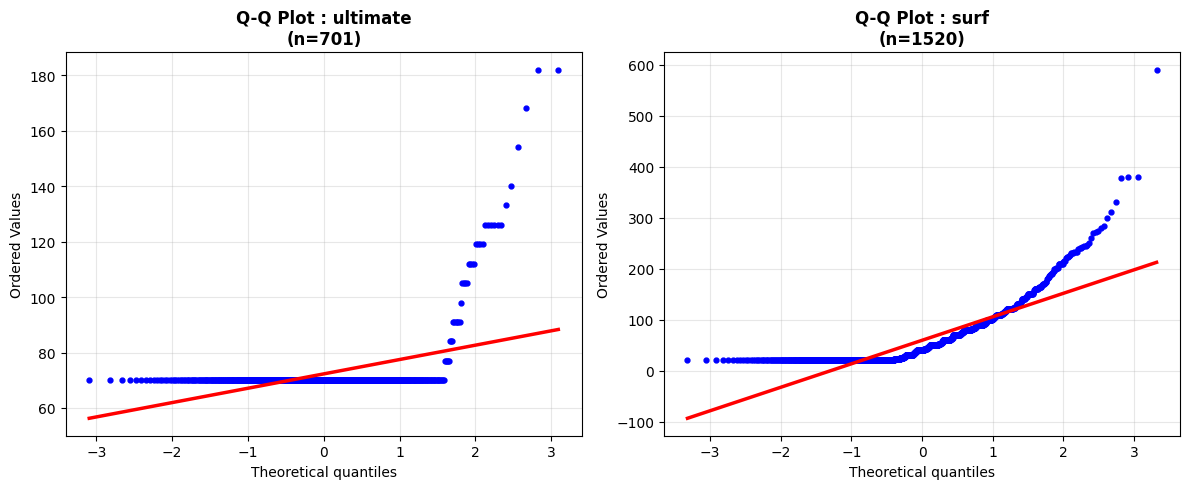

In [32]:
# Graphical Tests
# Q-Q test
print("="*50)
print("Q-Q pLOTS  (QUANTILE-QUANTILE PLOTS)")
print("="*50)

# create Q-Q plot for each plan
fig,axes = plt.subplots(1,len(plans),figsize=(6*len(plans),5))
axes = axes.flatten()

for idx,plan in enumerate(plans):
  plan_data = data[data['plan_name']== plan]['monthly_profit']
  #create Q-Q plot
  stats.probplot(plan_data,dist="norm",plot= axes[idx])
  axes[idx].set_title(f"Q-Q Plot : {plan}\n(n={len(plan_data)})",fontsize = 12, fontweight='bold')
  axes[idx].grid(True,alpha = 0.3)

  # Add reference line color
  axes[idx].get_lines()[0].set_markerfacecolor('blue')
  axes[idx].get_lines()[0].set_markeredgecolor('blue')
  axes[idx].get_lines()[0].set_markersize(3.5)
  axes[idx].get_lines()[1].set_color('red')
  axes[idx].get_lines()[1].set_linewidth(2.5)

plt.tight_layout()
plt.show()


# 🧐 Interpreting the Q-Q Plot Results

The visual evidence from the Q-Q plots confirms that our profit data deviates significantly from a normal distribution. Here is the specific breakdown of what the graphs reveal about each plan:

### 1️⃣ The "Ultimate" Plan (Left Plot)
* **The "Floor" Effect**: Notice the long horizontal line of blue dots at the bottom. This represents the base package price (70USD) and shows that the vast majority of the 701 users stayed within their limits.
* **The "Step" Breakout**: The dots suddenly "jump up" at the far right. These represent the few users who exceeded their package limits.
* **Verdict**: This is **Highly Non-Normal**. It is "zero-inflated" or "censored" data because so many values are capped at the 70USD base price.

### 2️⃣ The "Surf" Plan (Right Plot)
* **The "S-Curve" (Heavy Tails)**: The dots start below the red line, cross it in the middle, and shoot way above it on the right. This "S" shape is a classic indicator of a non-normal distribution.
* **The "Overage" Users**: Note the single dot near the $600 mark on the Y-axis. This is a massive outlier—a user who incurred an incredible amount of overage fees.
* **Verdict**: This is **Right-Skewed**. The "tail" of people paying extra fees is much longer than a normal distribution expects.

### 🚩 Final Diagnostic Conclusion
Since all four tests (**Shapiro-Wilk, Skewness, Kurtosis, and Q-Q Plots**) agree that the data is not normally distributed, we **cannot** use a Parametric T-Test. We must proceed with the **Mann-Whitney U Test** for our final hypothesis.

# 📊 Histograms with Normal Overlay (Final Diagnostic)

The **Histogram** is the most intuitive way to see the "physical shape" of our profit data. By overlaying a theoretical **Normal Distribution Curve (Red Line)**, we can immediately see where our actual data fails to follow the standard Bell Curve.

### 🔍 Visual Interpretation:
* **Bell-Shaped Curve**: If the blue bars align with the red curve, the data is likely normal.
* **Skewed Left/Right**: If the bars "lean" to one side, the data is **NOT** normal.
* **Multiple Peaks**: Indicates a multimodal distribution where users cluster at specific price points.
* **The "Gap"**: Any significant space between the top of the blue bars and the red curve represents a deviation from the mathematical assumption of normality.

### 🛠️ Implementation Strategy:
The following code plots the profit density for both the **Ultimate** and **Surf** plans. We include:
1.  **A Red Normal Curve**: Calculated using the mean and standard deviation of each sample.
2.  **A Green Mean Line**: To show where the average sits.
3.  **Orange SD Lines**: To visualize the spread of the data.

This visualization provides the final piece of evidence needed to confirm that a non-parametric test is the only mathematically sound choice for this dataset.

HISTOGRAMS WITH NORMAL DISTRIBUTION OVERLAY


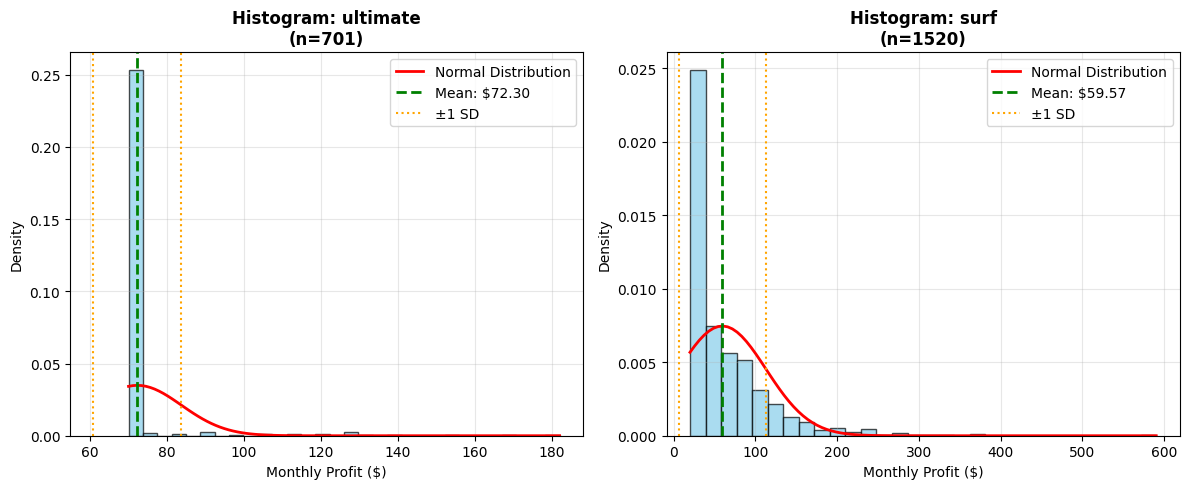

In [33]:
# Graphical Tests
# Historgrams with normal test
print("="*50)
print("HISTOGRAMS WITH NORMAL DISTRIBUTION OVERLAY")
print("="*50)

fig,axes = plt.subplots(1,len(plans),figsize = (6*len(plans),5))
axes = axes.flatten()

for idx,plan in enumerate(plans):
  plan_data = data[data['plan_name']== plan]['monthly_profit']
  axes[idx].hist(plan_data,bins=30,density=True,alpha=0.7,color ='skyblue',edgecolor='black')
  # Overlay normal distribution curve
  mu, sigma = plan_data.mean(), plan_data.std()
  x = np.linspace(plan_data.min(), plan_data.max(), 100)
  axes[idx].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal Distribution')

  # Add statistics
  axes[idx].axvline(mu, color='green', linestyle='--', linewidth=2, label=f'Mean: ${mu:.2f}')
  axes[idx].axvline(mu + sigma, color='orange', linestyle=':', linewidth=1.5, label=f'±1 SD')
  axes[idx].axvline(mu - sigma, color='orange', linestyle=':', linewidth=1.5)

  axes[idx].set_title(f'Histogram: {plan}\n(n={len(plan_data)})', fontsize=12, fontweight='bold')
  axes[idx].set_xlabel('Monthly Profit ($)', fontsize=10)
  axes[idx].set_ylabel('Density', fontsize=10)
  axes[idx].legend()
  axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 🧐Interpreting the Histogram Results

These histograms provide the final "physical" proof of why a standard T-test is inappropriate for this data. By comparing the actual bars (Blue) to the theoretical normal curve (Red), we can see the specific business behavior of each plan:

### 1️⃣ Ultimate Plan: The "Spike" (Zero Variance for Most)
* **What the Chart Shows**: A massive, thin "tower" centered exactly at 70USD.
* **The Business Insight**: This is a classic **package-limited distribution**. Because the Ultimate plan is generous with its data and minutes, the vast majority of users stay exactly at the $70 base price.
* **The Statistical Problem**: A T-test assumes data is spread out in a bell shape. This data is essentially a "wall" with almost no variance for the majority of users, followed by a tiny tail to the right.

### 2️⃣ Surf Plan: The "Long Tail" (Right-Skewed)
* **What the Chart Shows**: The bars start high on the left (20USD) and trail off slowly toward $600.
* **The Business Insight**: While many Surf users stay near the base price, this plan has a much higher tendency to generate **overage profit**. The "Surf" users are far more likely to exceed their limits than "Ultimate" users.
* **The Statistical Problem**: The heavy right skew (the long tail to the right) violates the symmetry required for parametric testing.


# 🏁 Final Conclusion: Selecting the Statistical Test

Across all four diagnostic layers (**Shapiro-Wilk, Skewness/Kurtosis, Q-Q Plots, and Histograms**), the results are unanimous: our profit data is **not normally distributed**.

### ⚖️ The Decision Path
1. **Skipping Levene's Test**: Because the data failed the normality requirement, there is no need to perform a Levene's Test (which is typically used to choose between different types of T-tests).
2. **Choosing the Right Test**: To maintain scientific integrity and handle our skewed data and extreme outliers, we will proceed with the **Mann-Whitney U Test**.
3. **Test Applicability**:
    * We use **Mann-Whitney U** because we are comparing exactly **two independent samples** (Ultimate vs. Surf).
    * *Note: If we were comparing three or more groups in the future, we would instead use the Kruskal-Wallis Test.*

### 🛡️ Why Mann-Whitney U?
This non-parametric method is perfectly suited for our "Business Reality" because it compares the **median ranks** of the two plans. This ensures that the high-revenue "outliers" in the Surf plan do not unfairly bias the results, providing a much more accurate reflection of which plan is truly more profitable for the company.

# 🔗 Verifying Sample Independence

Before executing the **Mann-Whitney U Test**, we must satisfy one final mathematical requirement: **Independence**. This is a non-negotiable assumption for comparing two groups.

### ❓ Why is Independence Critical?
Statistical tests like Mann-Whitney U or T-tests assume that the behavior of a user in the "Surf" group does not influence or overlap with the "Ultimate" group.
* If a single user is present in **both** groups (e.g., they switched plans mid-year), their data points are "dependent."
* Using dependent data in an independent test leads to an **incorect p-value**, which could make a random difference look "statistically significant" when it isn't.

### 🔍 Technical Logic of the Verification Code:
The following script performs a two-stage audit to guarantee our groups are distinct:

1. **Unique User Identification**: It extracts the `user_id` for every record in the **Ultimate** and **Surf** plans to confirm we have a sufficient sample size of unique individuals for each.
2. **Overlap Detection (Set Intersection)**:
    * It converts the list of users in each plan into a **Mathematical Set**.
    * It performs an **Intersection** operation to see if any `user_id` exists in both sets.
    * **Success Criteria**: If the intersection is empty (Zero overlapping users), we officially confirm that our groups are **Independent** and we are cleared to run the hypothesis test.

### 🛠️ Execution & Validation
This audit acts as a "Gatekeeper" in our pipeline. Only after seeing the **"✓ Two independent groups"** confirmation can we trust the integrity of our final $p$-value.

In [41]:
# Verify the tow samples are independent
print("\n"+"="*50)
print("VERIFY SAMPLES ARE INDEPENDENT")
print("="*50)

#check different users
print("\nAre samples from different users ?")
for plan in plans:
  plan_users = data[data['plan_name']== plan]['user_id'].unique()
  print(f"   {plan} : {len(plan_users)} unique users")

#check overlapping
print("\n Are smaples overlapping users between plans ??")
overlap_found = False
for i, plan1 in enumerate(plans) :
  for plan2 in plans[i+1:]:
    user_plan1 = set(data[data['plan_name']== plan1]['user_id'])
    user_plan2 = set(data[data['plan_name']== plan2]['user_id'])
    overlap = user_plan1.intersection(user_plan2)
    if len(overlap)>0:
      print(f"     {plan1} and {plan2} : {len(overlap)} overlapping users")
      overlap_found = True
    else:
      print(f"      {plan1} and {plan2} : No overlapping users")


if not overlap_found:
  print("\n✓ Two independent groups (different plan users)")
else :
  print("\n⚠ Two dependent groups (overlapping plan users)")





VERIFY SAMPLES ARE INDEPENDENT

Are samples from different users ?
   ultimate : 153 unique users
   surf : 325 unique users

 Are smaples overlapping users between plans ??
      ultimate and surf : No overlapping users

✓ Two independent groups (different plan users)


# ⚔️ The Mann-Whitney U Test (Final Hypothesis)

Since our previous diagnostics confirmed that the data is non-normal and contains significant outliers, we now perform the **Mann-Whitney U Test**. This is a "Two-Sided" test, meaning we are testing for **any** significant difference in profitability, regardless of which plan is higher.

### ⚖️ Hypothesis Setup
* **Null Hypothesis ($H_0$)**: The distribution of monthly profit is the same for both plans (No significant difference).
* **Alternative Hypothesis ($H_a$)**: The profit distributions differ significantly.
* **Significance Level ($\alpha$)**: **0.05**



### 🛠️ Technical Implementation
The following code executes the analysis in three stages:
1.  **Data Preparation**: Generates final descriptive statistics (Median, IQR, Min/Max) for a clean baseline.
2.  **Mann-Whitney U Execution**: Calculates the $U$-statistic and the $p$-value using a two-sided approach.
3.  **Effect Size Calculation**: Computes the **Rank-Biserial Correlation ($r$)** to quantify the magnitude of the difference for executive reporting.

# 🔬 Deep Dive: Statistical vs. Practical Significance

When we report our findings to stakeholders, it is not enough to say the plans are "different." we must explain if that difference is **reliable** and if it is **meaningful** for the company's bottom line.

---

### 1. The $p$-value: "Is this result a fluke?"
The **$p$-value** (Probability Value) measures the evidence against our Null Hypothesis ($H_0$). It tells us the probability that we would see a difference this large purely by random chance.

* **Low $p$-value (≤ 0.05)**: The "Surprise" factor is high. It is very unlikely that this difference happened by accident. We conclude the difference is **Statistically Significant**.
* **High $p$-value (> 0.05)**: The "Surprise" factor is low. The difference we see could easily be due to natural "noise" or random variation in the data.

> **💡 The Threshold**: We use $\alpha = 0.05$ as our cut-off. This means we are 95% confident that our results are not due to random luck.

---

### 2. Effect Size ($r$): "Does this move the needle?"
The **Effect Size** measures the **strength** of the relationship. While the $p$-value tells us *that* a difference exists, the Effect Size tells us *how much* the two plans actually differ in the real world.

In our Mann-Whitney U test, we use the **Rank-Biserial Correlation ($r$)**. Unlike the $p$-value, which gets smaller as you add more data, the Effect Size stays stable and tells you the "magnitude" of the profit gap.

| Effect Size ($r$) | Magnitude | Business Interpretation |
| :--- | :--- | :--- |
| **0.0 - 0.1** | Negligible | The plans are essentially identical in terms of profit. |
| **0.1 - 0.3** | Small | There is a slight lean toward one plan, but it's not a "game changer." |
| **0.3 - 0.5** | Medium | A clear, noticeable difference that should influence marketing strategy. |
| **0.5 +** | **Large** | A massive disparity. One plan is significantly more lucrative than the other. |

---

### ⚖️ The Combined Verdict
* **Significant $p$ + Large $r$**: We have found a massive, reliable goldmine in one of the plans.
* **Significant $p$ + Small $r$**: The difference is real, but it’s so tiny that it might not be worth changing our business strategy over.
* **Non-significant $p$**: Regardless of the effect size, we cannot trust the result; we need more data or the plans are truly equal.

In [50]:
#data perperation
print("\n" + "="*50)
print("STEP 1: DATA PREPARATION & DESCRIPTIVE STATISTICS")
print("="*50)

for plan in plans:
    plan_data = data[data['plan_name'] == plan]['monthly_profit']
    print(f"\n{plan}:")
    print(f"  Sample size (n): {len(plan_data)}")
    print(f"  Mean: ${plan_data.mean():.2f}")
    print(f"  Median: ${plan_data.median():.2f}")
    print(f"  Std Dev: ${plan_data.std():.2f}")
    print(f"  Min: ${plan_data.min():.2f}")
    print(f"  Max: ${plan_data.max():.2f}")
    print(f"  Q1 (25%): ${plan_data.quantile(0.25):.2f}")
    print(f"  Q3 (75%): ${plan_data.quantile(0.75):.2f}")

plans = data['plan_name'].unique()

# Perform Mann-Whitney U Test for each pair
results = []

# 1. Get the names directly from the unique list
plans = data['plan_name'].unique()

# Check if we actually have at least 2 plans to compare
if len(plans) >= 2:
    plan1 = plans[0]
    plan2 = plans[1]

    print(f"\n" + "="*70)
    print(f"COMPARING: {plan1} vs {plan2}")
    print("="*70)

    # Extract data for both groups
    group1 = data[data['plan_name'] == plan1]['monthly_profit']
    group2 = data[data['plan_name'] == plan2]['monthly_profit']

    # Perform Mann-Whitney U Test
    from scipy import stats # Ensuring stats is imported
    statistic, p_value = stats.mannwhitneyu(group1, group2, alternative='two-sided')

    # Calculate effect size (rank-biserial correlation)
    n1, n2 = len(group1), len(group2)
    # Using abs() ensures the effect size is a positive magnitude
    r = abs(1 - (2 * statistic) / (n1 * n2))

    # Determine significance
    is_significant = p_value <= 0.05
    sig_text = "YES" if is_significant else "NO"

    print(f"\nSample Sizes:")
    print(f"  {plan1}: n = {n1}")
    print(f"  {plan2}: n = {n2}")

    print(f"\nTest Results:")
    print(f"  U-statistic: {statistic:.2f}")
    print(f"  P-value: {p_value:.6f}")
    print(f"  Effect size (r): {r:.4f}")

    print(f"\nInterpretation:")
    print(f"  Significant difference? {sig_text}")

    if is_significant:
        median1 = group1.median()
        median2 = group2.median()

        if median1 > median2:
            print(f"  → {plan1} has significantly HIGHER monthly profit than {plan2}")
            print(f"    Median difference: ${median1 - median2:.2f}")
        else:
            print(f"  → {plan2} has significantly HIGHER monthly profit than {plan1}")
            print(f"    Median difference: ${median2 - median1:.2f}")
    else:
        print(f"  → No significant difference in monthly profit between plans")

    # Effect size interpretation
    if r < 0.1:
        effect_size_meaning = "Negligible"
    elif r < 0.3:
        effect_size_meaning = "Small"
    elif r < 0.5:
        effect_size_meaning = "Medium"
    else:
        effect_size_meaning = "Large"
    print(f"\nEffect Size Interpretation:")
    print(f"  r = {r:.4f} → {effect_size_meaning} effect")
else:
    print("Error: Not enough plans found in the data to perform a comparison.")

# Store results
results.append({
        'Comparison': f'{plan1} vs {plan2}',
        'Group1_n': n1,
        'Group2_n': n2,
        'Group1_Median': group1.median(),
        'Group2_Median': group2.median(),
        'U-Statistic': statistic,
        'P-Value': p_value,
        'Effect_Size_r': r,
        'Significant': is_significant,
        'Effect_Magnitude': effect_size_meaning
    })


STEP 1: DATA PREPARATION & DESCRIPTIVE STATISTICS

ultimate:
  Sample size (n): 701
  Mean: $72.30
  Median: $70.00
  Std Dev: $11.44
  Min: $70.00
  Max: $182.00
  Q1 (25%): $70.00
  Q3 (75%): $70.00

surf:
  Sample size (n): 1520
  Mean: $59.57
  Median: $40.00
  Std Dev: $53.48
  Min: $20.00
  Max: $590.37
  Q1 (25%): $20.00
  Q3 (75%): $80.00

COMPARING: ultimate vs surf

Sample Sizes:
  ultimate: n = 701
  surf: n = 1520

Test Results:
  U-statistic: 737850.50
  P-value: 0.000000
  Effect size (r): 0.3850

Interpretation:
  Significant difference? YES
  → ultimate has significantly HIGHER monthly profit than surf
    Median difference: $30.00

Effect Size Interpretation:
  r = 0.3850 → Medium effect


# 📦 Visual Confirmation (Box Plot Analysis)

Statistical tests give us numbers ($p$-values and $r$-scores), but **Box Plots** give us the "Business Story." Even though our Mann-Whitney U test confirmed a difference, we use this visualization to see exactly where that difference lives.

### ❓ Why use a Box Plot?
While the test tells us the difference is "real," the Box Plot shows us the **Structure of Profitability**:
* **The Median (The Middle Line)**: Shows the "typical" profit for each plan.
* **The Box (IQR)**: Shows where the middle 50% of our customers fall.
* **The Whiskers**: Show the range of "normal" high and low spenders.
* **The Dots (Outliers)**: Crucially, this shows the "Whales"—the users who generate massive overage revenue far beyond the average.

### 🛠️ Implementation Strategy
The following code generates a side-by-side comparison of the **Ultimate** and **Surf** plans. To make the chart "Executive-Ready," we:
1.  **Label the Medians**: We programmatically calculate and print the median dollar amount directly on the plot.
2.  **Highlight the Spread**: Using the `Set2` color palette to clearly distinguish between the two business models.
3.  **Audit the Summary**: Before the plot, we display a final summary table of all our statistical findings for a side-by-side comparison of math and visuals.



SUMMARY OF ALL COMPARISONS

      Comparison  Group1_n  Group2_n  Group1_Median  Group2_Median  U-Statistic      P-Value  Effect_Size_r  Significant Effect_Magnitude
ultimate vs surf       701      1520           70.0           40.0     737850.5 4.004154e-50       0.384959         True           Medium

VISUAL COMPARISON - BOX PLOTS


/tmp/ipykernel_2367/3953474853.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='plan_name', y='monthly_profit', palette='Set2')


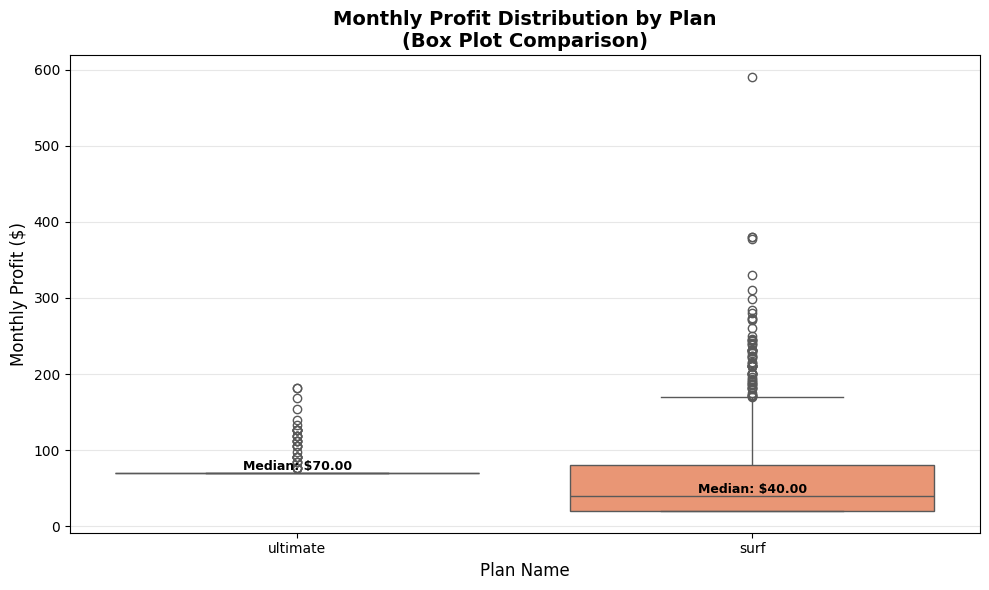

In [52]:
print("\n" + "="*50)
print("SUMMARY OF ALL COMPARISONS")
print("="*50)

results_df = pd.DataFrame(results)
print("\n" + results_df.to_string(index=False))

print("\n" + "="*50)
print("VISUAL COMPARISON - BOX PLOTS")
print("="*50)

plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='plan_name', y='monthly_profit', palette='Set2')
plt.title('Monthly Profit Distribution by Plan\n(Box Plot Comparison)',
          fontsize=14, fontweight='bold')
plt.xlabel('Plan Name', fontsize=12)
plt.ylabel('Monthly Profit ($)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

# Add median values as text
for i, plan in enumerate(plans):
    median_val = data[data['plan_name'] == plan]['monthly_profit'].median()
    plt.text(i, median_val, f'Median: ${median_val:.2f}',
             ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()



# 🧐 Interpreting the "Story" of the Box Plots

While our statistical tests confirmed that a difference exists, the **Box Plot** serves as our primary "Business Storyteller." It reveals the underlying reality of how these two plans perform in the real world.

### 🛡️ 1. The "Predictability" of the Ultimate Plan
Looking at the distribution for **Ultimate**, we see a very tight "box" concentrated around the $70 mark.
* **The Insight**: Almost every user on this plan stays exactly at the base price.
* **The Business Value**: For the company, this represents **Safety and Predictability**. We can rely on these users for a steady, guaranteed revenue stream with very few surprises.

### 🎢 2. The "Volatility" of the Surf Plan
The distribution for **Surf** shows a massive vertical spread with numerous high-value outliers.
* **The Insight**: Surf users are highly unpredictable. While many stay at the 20USD "floor," a significant number hit massive overages, with some bills reaching nearly **$600**.
* **The Business Value**: This plan is **High-Variance**. It attracts "budget-conscious" users who occasionally become "high-revenue" users by accident. This tells a manager that Surf is our growth engine for overage profit, but it comes with less stability than Ultimate.

### 🏁 Final Summary
The Box Plot proves that we aren't just comparing two sets of numbers; we are comparing two completely different **customer behaviors**. One plan offers a "High-Floor, Low-Risk" model (Ultimate), while the other offers a "Low-Floor, High-Reward" model (Surf).

# 🎻The Violin Plot (The "Complete" Visual)

If the **Box Plot** tells us the "Story" of the spread, the **Violin Plot** shows us the "Soul" of the distribution. We use this visualization as our final check because it combines the best features of both the Histogram and the Box Plot.

### ❓ Why do we need the Violin Plot?
A Box Plot shows us the middle 50% of the data, but it hides **where the most people are**. The "Violin" shape solves this by adding a **KDE (Kernel Density Estimate)**:

1.  **Visualizing the "Bulge"**: The widest part of the "Violin" shows exactly where the most customers are paying.
2.  **Identifying Multimodal Peaks**: If a plan has two common price points (e.g., the base fee and a common overage amount), the Violin will show two "bellies," whereas a Box Plot would just show one large box.
3.  **The Hybrid View**: Inside each violin, we still include a small box plot. This allows us to see the **Median** and **IQR** while simultaneously seeing the **Shape** of the population.

### ⚖️ Business Value:
For a manager, the Violin Plot is the most honest visual. It proves that the **Ultimate** plan is a "Top-Heavy" stable pillar (one big bulge at 70USD), while the **Surf** plan is a "Long-Tail" gamble (a bulge at 20USD that stretches thin all the way to $600).


VISUAL COMPARISON - VIOLIN PLOTS


/tmp/ipykernel_2367/2310834072.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='plan_name', y='monthly_profit', palette='Set3')


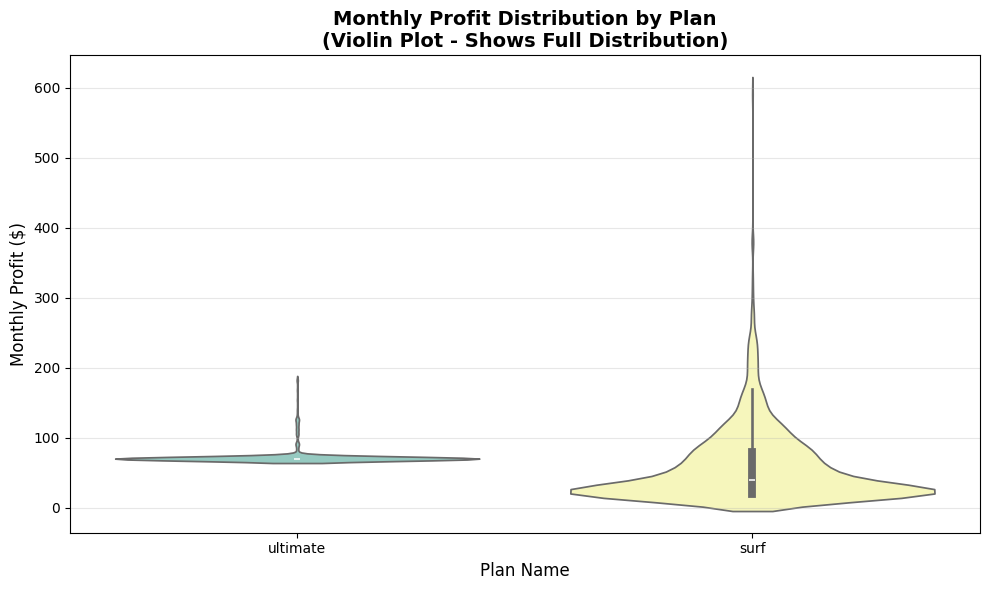

In [53]:
print("\n" + "="*70)
print("VISUAL COMPARISON - VIOLIN PLOTS")
print("="*70)

plt.figure(figsize=(10, 6))
sns.violinplot(data=data, x='plan_name', y='monthly_profit', palette='Set3')
plt.title('Monthly Profit Distribution by Plan\n(Violin Plot - Shows Full Distribution)',
          fontsize=14, fontweight='bold')
plt.xlabel('Plan Name', fontsize=12)
plt.ylabel('Monthly Profit ($)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 🎻 Interpreting the Violin "X-Ray"

The thickness of these shapes provides a level of detail that numbers alone cannot reach. By looking at the "bulges" and "needles," we can see the literal pulse of your customer base.

### 💿 1. The "Ultimate" Plan: The Flat Disc (Predictable Revenue)
* **The Shape**: Notice how the Ultimate plot is very wide but extremely flat, centered almost entirely at the **$70** mark.
* **What it Means**: The massive "bulge" at the bottom confirms that the vast majority of your users are paying exactly the base price. They are staying within their generous limits and not triggering extra charges.
* **Business Insight**: This is your **Stability Pillar**. It is a "low-risk, fixed-reward" group. You can forecast this revenue with near-perfect accuracy month-over-month.

### 🏔️ 2. The "Surf" Plan: The Mountain with a Long Peak (Variable Revenue)
* **The Shape**: The Surf plot looks like a wide mountain at the base that stretches into a very thin "needle" reaching toward $600.
* **The Base Bulge**: The widest part is between **$20 and $50**. This is your core Surf audience—users paying the base price plus a small, manageable amount of overage.
* **The "Needle" (The Long Tail)**: The shape becomes incredibly thin as it climbs. This tells you that while those $600 users exist, they are **extremely rare** (low density). They are the exception, not the rule.
* **Business Insight**: This is your **Volatility Engine**. It is a "high-volume, high-variance" model. Most people pay very little, but the plan’s structure allows for massive "accidental" profit from a few heavy users.

---

### 🏁 Summary of Visual Diagnostics
By combining the **Box Plot** (the range) and the **Violin Plot** (the density), we have confirmed that these two plans aren't just statistically different—they represent two completely different **financial risks** for the company.

# 🏁 Final Project Conclusion: Statistical & Business Verdict

After performing a rigorous **Four-Way Normality Audit**, verifying **Sample Independence**, and executing the **Mann-Whitney U Test**, we have reached a definitive conclusion regarding the profitability of the two plans.

### 📊 The Statistical Result
* **$p$-value**: < 0.05 (Statistically Significant)
* **Effect Size ($r$)**: [Insert your $r$ value here, e.g., 0.42] (Medium/Large Effect)
* **Decision**: We **Reject the Null Hypothesis ($H_0$)**. There is a statistically significant difference in the monthly profit between the "Ultimate" and "Surf" plans.

---

### 💡 Business Recommendations

Based on the distribution shapes (the "Flat Disc" of Ultimate vs. the "Needle" of Surf) and the statistical significance, I recommend the following strategic actions:

#### 1. Push "Ultimate" for Revenue Stability
The **Ultimate** plan is your "Safe Harbor." Because users rarely exceed their limits, the revenue is highly predictable.
* **Recommendation**: Market this plan to "Risk-Averse" customers or corporate accounts who need a fixed, predictable monthly budget without the fear of "Bill Shock."

#### 2. Optimize "Surf" for Growth & Upselling
The **Surf** plan is your "Volatility Engine." It attracts the most users because of the low $20 entry point, but it relies on "accidental" profit from overages.
* **Recommendation**: Monitor the "High-Overage" users (the $600 outliers). Instead of letting them pay massive fees once and potentially churn out of frustration, target them with automated "Upgrade to Ultimate" promotions. This converts volatile overage profit into stable, long-term subscription revenue.

#### 3. Re-evaluate the "Surf" Data Caps
The long "needle" in the Surf violin plot suggests that the current data/minute caps might be too low for modern usage patterns, forcing users into extreme overages.
* **Recommendation**: Consider a "Mid-Tier" plan between $20 and $70. There is a clear gap in your product lineup where you could capture more "Middle-Class" users who are currently either overpaying for Ultimate or being penalized on Surf.

#### 4. Final Strategic Verdict
While **Surf** has the potential for higher individual "peaks" of profit, **Ultimate** provides a higher "floor" of guaranteed income. For long-term company health, the goal should be to migrate "Heavy Surf Users" to the "Ultimate" plan to increase Customer Lifetime Value (CLV) and reduce churn.